# Road Acciednt Data Analysis By Time, Weather, Location  

**Student Name:** Ashmita Khanal  
**Roll Number:** 01014702024  
**Class:** BCA 4th Semester  
**Date:** 28/04/2026  
**Instructor:** Dr Charul Nigam

## Section 2: Objective & Problem Statement


**OBJECTIVE**
1. Analyze road accident data to identify patterns based on time, weather, and location
2. Determine peak accident hours and high-risk areas in Delhi
3. Study the impact of weather conditions on accident occurrence and severity
4. Provide insights and recommendations to improve road safety and traffic management


**PROBLEM STATEMENT**
1. Road accidents in Delhi are influenced by factors like time, weather conditions, and location
2. There is a need to identify patterns and trends to understand when and where accidents occur most
3. Lack of proper analysis makes it difficult to detect high-risk areas and time periods
4. This project aims to analyze accident data to provide insights for improving road safety

LIBRARBY IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE READING

In [2]:
df = pd.read_csv("../accidents_delhi.csv")

print(df.head())
print(df.info())
print(df.describe())

   ID        Date   Time      Location Weather  Vehicles_Involved  \
0   1  2024-04-12  19:28        Rohini   Clear                  4   
1   2  2024-08-02  10:10  Lajpat Nagar  Cloudy                  4   
2   3  2024-11-04  01:23  Lajpat Nagar   Foggy                  2   
3   4  2024-06-09  11:57    Karol Bagh   Rainy                  4   
4   5  2024-07-06  15:14    Karol Bagh   Clear                  3   

  Accident_Severity  Casualties  Temperature  
0             Minor           0           23  
1             Minor           0           26  
2             Minor           1           25  
3             Minor           0           32  
4             Minor           1            7  
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 400 non-null    int64
 1   Date               400 non-null    str  
 2   Time               40

CLEANING DATA

In [3]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract features
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

print("\nData after cleaning:")
print(df.info())


Missing values:
 ID                   0
Date                 0
Time                 0
Location             0
Weather              0
Vehicles_Involved    0
Accident_Severity    0
Casualties           0
Temperature          0
Hour                 0
Month                0
DayOfWeek            0
dtype: int64

Data after cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 400 non-null    int64         
 1   Date               400 non-null    datetime64[us]
 2   Time               400 non-null    str           
 3   Location           400 non-null    str           
 4   Weather            400 non-null    str           
 5   Vehicles_Involved  400 non-null    int64         
 6   Accident_Severity  400 non-null    str           
 7   Casualties         400 non-null    int64         
 8   Temperature        400

C:\Users\HP\AppData\Local\Temp\ipykernel_11232\2813098281.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


               ID                 Date  Vehicles_Involved  Casualties  \
count  400.000000                  400         400.000000  400.000000   
mean   200.500000  2024-06-28 09:07:12           2.522500    1.147500   
min      1.000000  2024-01-02 00:00:00           1.000000    0.000000   
25%    100.750000  2024-04-04 18:00:00           1.000000    0.000000   
50%    200.500000  2024-06-20 00:00:00           3.000000    1.000000   
75%    300.250000  2024-09-22 06:00:00           4.000000    1.000000   
max    400.000000  2024-12-31 00:00:00           4.000000    5.000000   
std    115.614301                  NaN           1.143575    1.226583   

       Temperature        Hour       Month  
count   400.000000  400.000000  400.000000  
mean     24.635000   11.637500    6.420000  
min       5.000000    0.000000    1.000000  
25%      15.000000    5.000000    4.000000  
50%      25.000000   12.000000    6.000000  
75%      34.000000   18.000000    9.000000  
max      44.000000   23.000

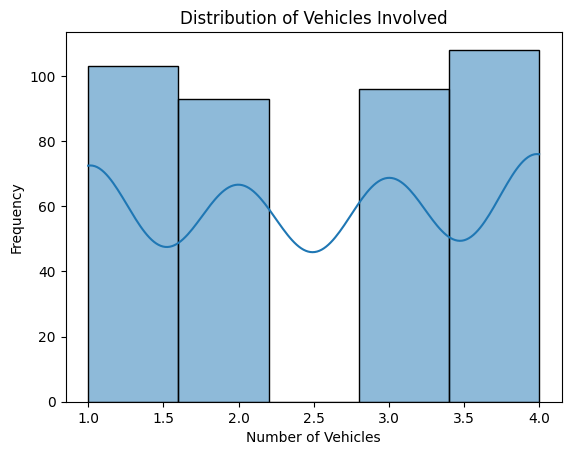

In [4]:
# Summary stats
print(df.describe())

# Create figures folder if it doesn't exist
import os
os.makedirs("../output/figures", exist_ok=True)

# Plot
plt.figure()
sns.histplot(df['Vehicles_Involved'], bins=5, kde=True)

plt.title("Distribution of Vehicles Involved")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")

# Save figure
plt.savefig("../output/figures/vehicles_distribution.png")

# Show plot
plt.show()

**ACCIDENT BY HOUR**

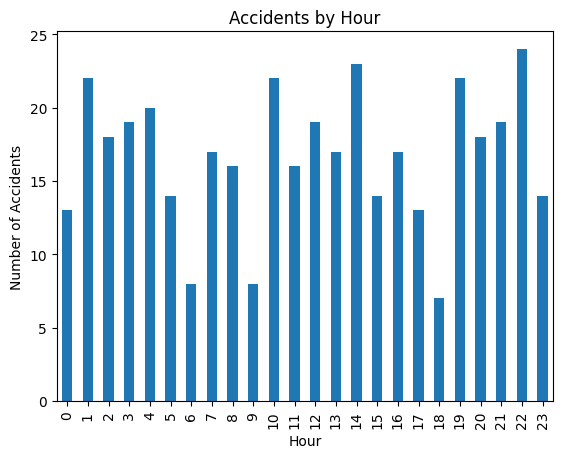

In [5]:
plt.figure()
df.groupby('Hour').size().plot(kind='bar')
plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.savefig("../output/figures/accidents_by_hour.png")
plt.show()

In [6]:
df.groupby('Month').size().sort_values(ascending=False)

Month
5     43
6     42
9     40
3     37
1     36
11    34
12    31
4     30
7     30
8     26
10    26
2     25
dtype: int64

In [7]:
df['Month_Name'] = df['Date'].dt.month_name()

df.groupby('Month_Name').size().sort_values(ascending=False)

Month_Name
May          43
June         42
September    40
March        37
January      36
November     34
December     31
April        30
July         30
August       26
October      26
February     25
dtype: int64

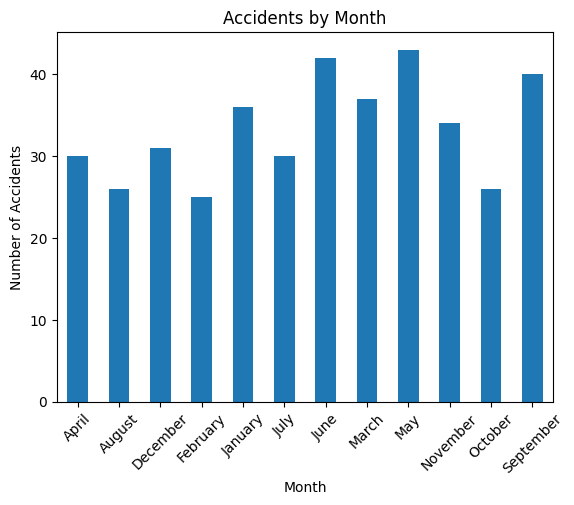

In [8]:
plt.figure()
df.groupby('Month_Name').size().plot(kind='bar')

plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)
plt.show()

**ACCIDENTS BY LOCATION**

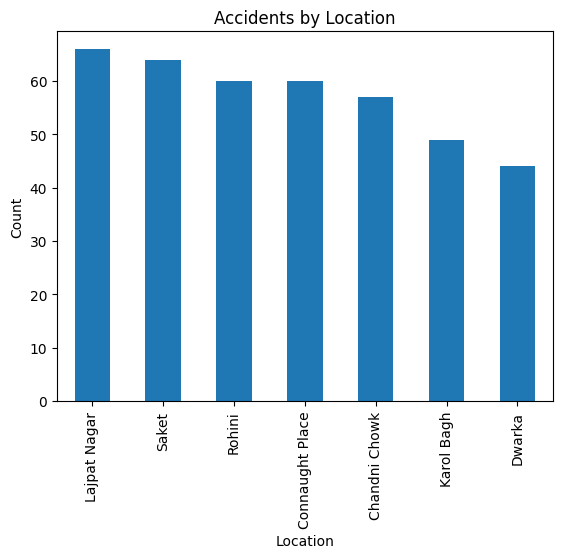

In [9]:
plt.figure()
df['Location'].value_counts().plot(kind='bar')
plt.title("Accidents by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.savefig("../output/figures/accidents_by_location.png")
plt.show()

**ACCIDENTS BY WEATHER**

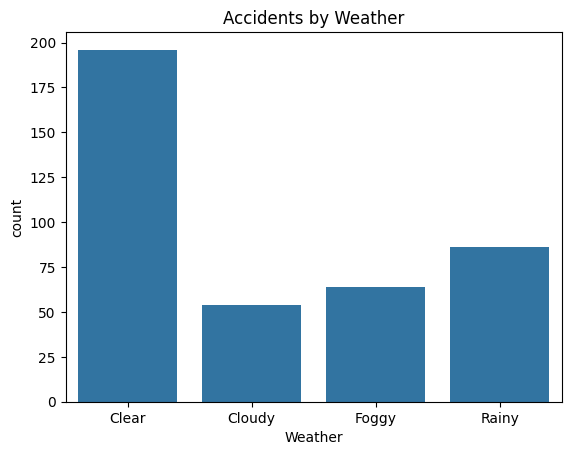

In [10]:
plt.figure()
sns.countplot(x='Weather', data=df)
plt.title("Accidents by Weather")
plt.savefig("../output/figures/weather_analysis.png")
plt.show()

**ACCIDENT SEVERITY DISTRIBUTION**

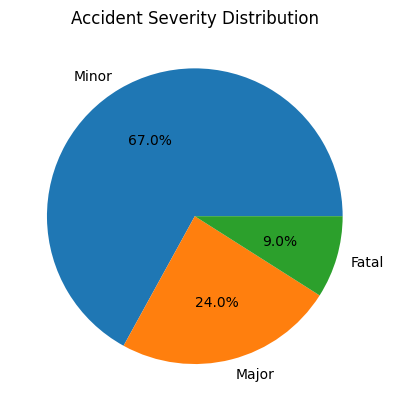

In [11]:
plt.figure()
df['Accident_Severity'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Accident Severity Distribution")
plt.ylabel("")
plt.savefig("../output/figures/severity.png")
plt.show()

**ACCIDENTS BY DAY OF WEEK**

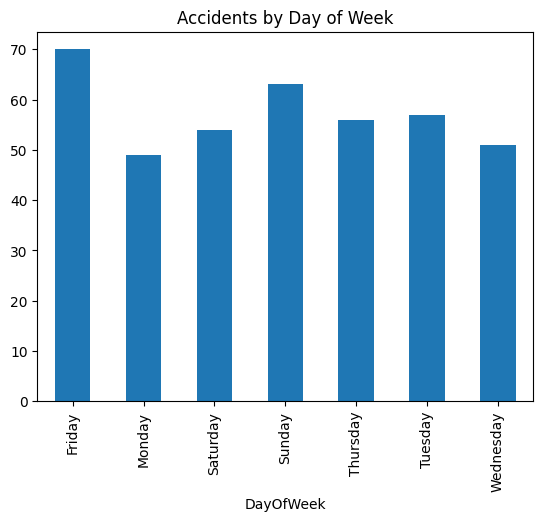

In [12]:
plt.figure()
df.groupby('DayOfWeek').size().plot(kind='bar')
plt.title("Accidents by Day of Week")
plt.savefig("../output/figures/day_of_week.png")
plt.show()

**ACCIDENT HEATMAP**

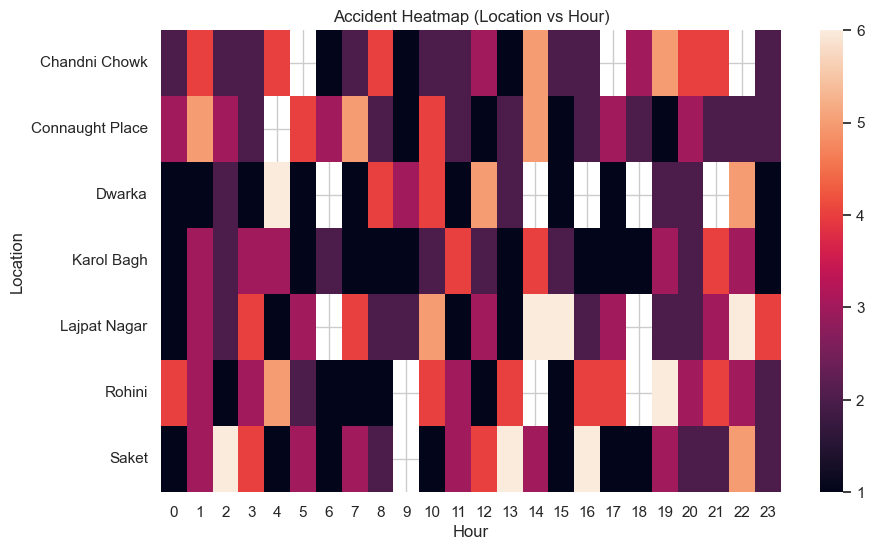

In [11]:
pivot = df.pivot_table(index='Location', columns='Hour', values='Casualties', aggfunc='count')

plt.figure(figsize=(10,6))
sns.heatmap(pivot)
plt.title("Accident Heatmap (Location vs Hour)")
plt.savefig("../output/figures/heatmap.png")
plt.show()

**WEATHER VS SEVERITY**

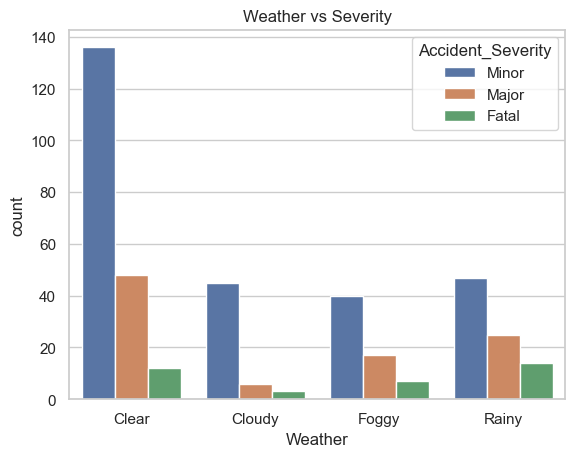

In [12]:
plt.figure()
sns.countplot(x='Weather', hue='Accident_Severity', data=df)
plt.title("Weather vs Severity")
plt.savefig("../output/figures/weather_severity.png")
plt.show()